# Kaggle Competition: Binary Text Classification

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import pandas as pd
import string
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords 
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from nltk.stem import WordNetLemmatizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgbm
from sklearn.linear_model import LogisticRegression
from sklearn import model_selection, naive_bayes, svm
from sklearn.svm import SVC

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Common\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Common\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Common\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Table of Contents

* [Data Preprocessing](#Data Preprocessing)
    * [Explore](#Explore)
* [The Vector Space Model and a Search Engine](#The-Vector-Space-Model-and-a-Search-Engine)
    * [In Code](#In-Code)
* [Naive Bayes](#Naive-Bayes)
    * [Multinomial Naive Bayes and Other Likelihood Functions](#Multinomial-Naive-Bayes-and-Other-Likelihood-Functions)
    * [Picking Hyperparameters for Naive Bayes and Text Maintenance](#Picking-Hyperparameters-for-Naive-Bayes-and-Text-Maintenance)
* [Interpretation](#Interpretation)

## Explore The Dataset

### Get The Dataset

In [2]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

### Explore Train Dataset

In [3]:
# Check the number of missing values
df_train.isnull().sum()

Comment    0
Outcome    0
Id         0
dtype: int64

In [4]:
# Number of rows in train dataset
n_row_train = len(df_train)
print("Number of row in train dataset: {:d}".format(n_row_train))

Number of row in train dataset: 44183


In [5]:
# Display sample data of train dataset
df_train.head()

,Comment,Outcome,Id
0,combining lindelof's and gregg lind's ideas: l...,1,2994
1,in most cases r is an interpreted language tha...,1,22730
2,you can drop any row containing a missing usin...,1,49407
3,you need to use strptime() to convert the stri...,1,26239
4,"i'm no r expert, but most languages use a refe...",1,35866


In [6]:
# Number of words in train dataset
df_train['Comment'].apply(lambda x: len(x.split(' '))).sum()

4464302

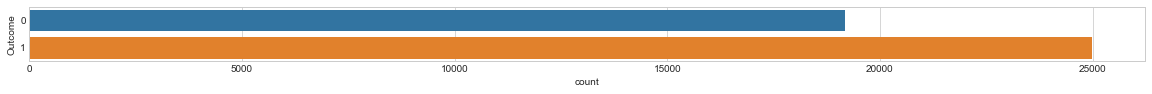

In [7]:
plt.style.use('seaborn-whitegrid')
fig = plt.figure(figsize=(20,1)) 
sns.countplot(y='Outcome', data=df_train);

### Explore Test Dataset

In [8]:
# Check the number of missing values
df_test.isnull().sum()

Comment    0
Id         0
dtype: int64

In [9]:
# Number of rows in test dataset
n_row_test = len(df_test)
print("Number of row in test dataset: {:d}".format(n_row_test))

Number of row in test dataset: 28200


In [10]:
# Display sample data of test dataset
df_test.head()

,Comment,Id
0,use variables in the outer function instead of...,68045
1,if you're looking for something as nice as pyt...,60790
2,"i use the tail() function: tail(vector, n=1) t...",53896
3,clearly i should have worked on this for anoth...,50204
4,"you are, indeed, passing the object around and...",60771


In [11]:
# Number of words in test dataset
df_test['Comment'].apply(lambda x: len(x.split(' '))).sum()

2904667

## Data Preprocessing

In [12]:
stop_words = set(stopwords.words('english')) 
stemmer = WordNetLemmatizer()

In [13]:
def clean(s):
    s = s.replace(r'<lb>', "\n")
    s = s.replace('[^\w\s]', " ")
    s = s.replace(r'<tab>', "\i")
    s = re.sub(r'<br */*>', "\n", s)
    s = s.replace("&lt;", "<").replace("&gt;", ">").replace("&amp;", "&")
    s = s.replace("&amp;", "&")
    s = s.replace('[^0-9a-z #+_]'," ")
    s = s.replace('[/(){}\[\]\|@,;]'," ")
    
    # markdown urls
    s = re.sub(r'\(https*://[^\)]*\)', "", s)
    
    # normal urls 
    s = re.sub(r'https*://[^\s]*', "", s)
    s = re.sub(r'_+', ' ', s)
    s = re.sub(r'"+', '"', s)
    
    # Remove single characters from the start
    s = re.sub(r'\^[a-zA-Z]\s+', ' ', s)
    
    # Substituting multiple spaces with single space
    s = re.sub(r'\s+', ' ', s, flags=re.I)
    
    # change to lowercase
    s = s.lower()    
    
    # stopwords
    s = ' '.join(word for word in s.split() if word not in stop_words)
    
    # remove whitespace
    s = ' '.join(s.split())
    
    # Lemmatization
    s = s.split()
    s = [stemmer.lemmatize(word) for word in s]
    s = ' '.join(s)
    
    return str(s)

In [14]:
# Function to remove punctuations
def remove_punctuations(s):
    words = nltk.word_tokenize(s)
    punt_removed= [w for w in words if w.lower() not in string.punctuation]
    return " ".join(punt_removed)

In [15]:
# Create a new column for the clean data
df_train["Comment_Clean"] = ''
df_test["Comment_Clean"] = ''

In [16]:
# Clean the data and put it into the new column: Comment_Clean

# Training dataset
for i, row in df_train.iterrows():
    df_train.at[i, "Comment_Clean"] = clean(row.Comment)
    df_train.at[i, "Comment_Clean"] = remove_punctuations(row.Comment)
    
# test dataset
for i, row in df_test.iterrows():
    df_test.at[i, "Comment_Clean"] = clean(row.Comment)
    df_test.at[i, "Comment_Clean"] = remove_punctuations(row.Comment)

In [17]:
# Check train dataset
df_train.head()

,Comment,Outcome,Id,Comment_Clean
0,combining lindelof's and gregg lind's ideas: l...,1,2994,combining lindelof 's and gregg lind 's ideas ...
1,in most cases r is an interpreted language tha...,1,22730,in most cases r is an interpreted language tha...
2,you can drop any row containing a missing usin...,1,49407,you can drop any row containing a missing usin...
3,you need to use strptime() to convert the stri...,1,26239,you need to use strptime to convert the string...
4,"i'm no r expert, but most languages use a refe...",1,35866,i 'm no r expert but most languages use a refe...


In [18]:
# Check test dataset
df_test.head()

,Comment,Id,Comment_Clean
0,use variables in the outer function instead of...,68045,use variables in the outer function instead of...
1,if you're looking for something as nice as pyt...,60790,if you 're looking for something as nice as py...
2,"i use the tail() function: tail(vector, n=1) t...",53896,i use the tail function tail vector n=1 the ni...
3,clearly i should have worked on this for anoth...,50204,clearly i should have worked on this for anoth...
4,"you are, indeed, passing the object around and...",60771,you are indeed passing the object around and u...


In [19]:
# Split the train dataset into train and validation
X_train, X_val, y_train, y_val = train_test_split(df_train['Comment_Clean'], df_train['Outcome'], test_size=0.2, random_state=0)

## Feature Engineering

In [20]:
# Create vectors
vectorizer= TfidfVectorizer(sublinear_tf=True, smooth_idf= True, max_df=0.5, ngram_range=(1, 2), stop_words='english')
X_train_vect= vectorizer.fit_transform(X_train)
X_val_vect= vectorizer.transform(X_val)

## Explore The Models

### SVM

In [21]:
%%time
SVM = svm.SVC(C=1.0, kernel='linear', degree=3, gamma='auto')
SVM.fit(X_train_vect,y_train)

Wall time: 40min 26s


In [45]:
y_train_pred_svm = SVM.predict(X_train_vect)
y_val_pred_svm = SVM.predict(X_val_vect)

In [46]:
print("Confusion Matrix of SVM Model (training dataset):")
tn, fp, fn, tp = confusion_matrix(y_train, y_train_pred_svm).ravel()
print("TN = {}, FP = {}, FN = {}, TP = {}\n".format(tn, fp, fn, tp)) 

print("\nClassification Report of SVM Model (training dataset): \n", classification_report(y_train, y_train_pred_svm))
print("\nAccuracy Score of SVM Model (training dataset): ", accuracy_score(y_train, y_train_pred_svm))

Confusion Matrix of SVM Model (training dataset):
TN = 14766, FP = 635, FN = 289, TP = 19656


Classification Report of SVM Model (training dataset): 
              precision    recall  f1-score   support

          0       0.98      0.96      0.97     15401
          1       0.97      0.99      0.98     19945

avg / total       0.97      0.97      0.97     35346


Accuracy Score of SVM Model (training dataset):  0.9738584281106774


In [47]:
print("Confusion Matrix of SVM Model (validation dataset):")
tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred_svm).ravel()
print("TN = {}, FP = {}, FN = {}, TP = {}\n".format(tn, fp, fn, tp)) 

print("\nClassification Report of SVM Model (validation dataset): \n", classification_report(y_val, y_val_pred_svm))
print("\nAccuracy Score of SVM Model (validation dataset): ", accuracy_score(y_val, y_val_pred_svm))

Confusion Matrix of SVM Model (validation dataset):
TN = 2136, FP = 1654, FN = 868, TP = 4179


Classification Report of SVM Model (validation dataset): 
              precision    recall  f1-score   support

          0       0.71      0.56      0.63      3790
          1       0.72      0.83      0.77      5047

avg / total       0.71      0.71      0.71      8837


Accuracy Score of SVM Model (validation dataset):  0.7146090302138735


### LightGBM

In [48]:
%%time
lgb = lgbm.LGBMClassifier(max_depth=3, learning_rate=0.1, n_estimators=1000)
lgb_model = lgb.fit(X_train_vect, y_train)

Wall time: 46 s


In [49]:
y_train_pred_lgb= lgb_model.predict(X_train_vect)
y_val_pred_lgb = lgb_model.predict(X_val_vect)

C:\Users\Common\Anaconda3\lib\site-packages\sklearn\preprocessing\label.py:151: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if diff:
C:\Users\Common\Anaconda3\lib\site-packages\sklearn\preprocessing\label.py:151: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if diff:


In [50]:
print("Confusion Matrix of LightGBM Model (training dataset):")
tn, fp, fn, tp = confusion_matrix(y_train, y_train_pred_lgb).ravel()
print("TN = {}, FP = {}, FN = {}, TP = {}\n".format(tn, fp, fn, tp)) 


print("\nClassification Report of LightGBM Model (training dataset): \n", classification_report(y_train, y_train_pred_lgb))
print("\nAccuracy Score of LightGBM Model (training dataset): ", accuracy_score(y_train, y_train_pred_lgb))

Confusion Matrix of LightGBM Model (training dataset):
TN = 11062, FP = 4339, FN = 3519, TP = 16426


Classification Report of LightGBM Model (training dataset): 
              precision    recall  f1-score   support

          0       0.76      0.72      0.74     15401
          1       0.79      0.82      0.81     19945

avg / total       0.78      0.78      0.78     35346


Accuracy Score of LightGBM Model (training dataset):  0.7776834719628812


In [51]:
print("Confusion Matrix of LightGBM Model (validation dataset):")
tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred_lgb).ravel()
print("TN = {}, FP = {}, FN = {}, TP = {}\n".format(tn, fp, fn, tp)) 

print("\nClassification Report of LightGBM Model (validation dataset): \n", classification_report(y_val, y_val_pred_lgb))
print("\nAccuracy Score of LightGBM Model (validation dataset): ", accuracy_score(y_val, y_val_pred_lgb))

Confusion Matrix of LightGBM Model (validation dataset):
TN = 2578, FP = 1212, FN = 1362, TP = 3685


Classification Report of LightGBM Model (validation dataset): 
              precision    recall  f1-score   support

          0       0.65      0.68      0.67      3790
          1       0.75      0.73      0.74      5047

avg / total       0.71      0.71      0.71      8837


Accuracy Score of LightGBM Model (validation dataset):  0.708724680321376


### Logistics Regression

In [52]:
%%time
logistics_model = LogisticRegression()
logistics_model.fit(X_train_vect, y_train)

Wall time: 4.1 s


In [53]:
y_train_pred_logistics = logistics_model.predict(X_train_vect)
y_val_pred_logistics = logistics_model.predict(X_val_vect)

In [54]:
print("Confusion Matrix of Logistics Regression Model (training dataset):")
tn, fp, fn, tp = confusion_matrix(y_train, y_train_pred_logistics).ravel()
print("TN = {}, FP = {}, FN = {}, TP = {}\n".format(tn, fp, fn, tp)) 

print("\nClassification Report of Logistics Regression Model (training dataset): \n", classification_report(y_train, y_train_pred_logistics))
print("\nAccuracy Score of Logistics Regression Model (training dataset): ", accuracy_score(y_train, y_train_pred_logistics))

Confusion Matrix of Logistics Regression Model (training dataset):
TN = 12629, FP = 2772, FN = 1076, TP = 18869


Classification Report of Logistics Regression Model (training dataset): 
              precision    recall  f1-score   support

          0       0.92      0.82      0.87     15401
          1       0.87      0.95      0.91     19945

avg / total       0.89      0.89      0.89     35346


Accuracy Score of Logistics Regression Model (training dataset):  0.8911333672834267


In [55]:
print("Confusion Matrix of Logistics Regression Model (validation dataset):")
tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred_logistics).ravel()
print("TN = {}, FP = {}, FN = {}, TP = {}\n".format(tn, fp, fn, tp)) 

print("\nClassification Report of Logistics Regression Model (validation dataset): \n", classification_report(y_val, y_val_pred_logistics))
print("\nAccuracy Score of Logistics Regression Model (validation dataset): ", accuracy_score(y_val, y_val_pred_logistics))

Confusion Matrix of Logistics Regression Model (validation dataset):
TN = 1959, FP = 1831, FN = 755, TP = 4292


Classification Report of Logistics Regression Model (validation dataset): 
              precision    recall  f1-score   support

          0       0.72      0.52      0.60      3790
          1       0.70      0.85      0.77      5047

avg / total       0.71      0.71      0.70      8837


Accuracy Score of Logistics Regression Model (validation dataset):  0.7073667534231074


### XGBoost

In [56]:
%%time
xgb = XGBClassifier(max_depth=3, learning_rate=0.1, n_estimators=100)
xgb_model = xgb.fit(X_train_vect, y_train)

Wall time: 2min 45s


In [57]:
y_train_pred_xgb= xgb_model.predict(X_train_vect)
y_val_pred_xgb= xgb_model.predict(X_val_vect)

C:\Users\Common\Anaconda3\lib\site-packages\sklearn\preprocessing\label.py:151: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if diff:
C:\Users\Common\Anaconda3\lib\site-packages\sklearn\preprocessing\label.py:151: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if diff:


In [58]:
print("Confusion Matrix of XGBoost Model (training dataset):")
tn, fp, fn, tp = confusion_matrix(y_train, y_train_pred_xgb).ravel()
print("TN = {}, FP = {}, FN = {}, TP = {}\n".format(tn, fp, fn, tp)) 


print("\nClassification Report of XGBoost Model (training dataset): \n", classification_report(y_train, y_train_pred_xgb))
print("\nAccuracy Score of XGBoost Model (training dataset): ", accuracy_score(y_train, y_train_pred_xgb))

Confusion Matrix of XGBoost Model (training dataset):
TN = 9095, FP = 6306, FN = 4914, TP = 15031


Classification Report of XGBoost Model (training dataset): 
              precision    recall  f1-score   support

          0       0.65      0.59      0.62     15401
          1       0.70      0.75      0.73     19945

avg / total       0.68      0.68      0.68     35346


Accuracy Score of XGBoost Model (training dataset):  0.6825666270582245


In [59]:
print("Confusion Matrix of XGBoost Model (validation dataset):")
tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred_xgb).ravel()
print("TN = {}, FP = {}, FN = {}, TP = {}\n".format(tn, fp, fn, tp)) 

print("\nClassification Report of XGBoost Model (validation dataset): \n", classification_report(y_val, y_val_pred_xgb))
print("\nAccuracy Score of XGBoost Model (validation dataset): ", accuracy_score(y_val, y_val_pred_xgb))

Confusion Matrix of XGBoost Model (validation dataset):
TN = 2472, FP = 1318, FN = 1610, TP = 3437


Classification Report of XGBoost Model (validation dataset): 
              precision    recall  f1-score   support

          0       0.61      0.65      0.63      3790
          1       0.72      0.68      0.70      5047

avg / total       0.67      0.67      0.67      8837


Accuracy Score of XGBoost Model (validation dataset):  0.6686658368224511


### AdaBoost

In [60]:
%%time
DTC = DecisionTreeClassifier(max_depth = 3)
abc = AdaBoostClassifier(base_estimator=DTC, learning_rate=1, n_estimators=10)
abc_model = abc.fit(X_train_vect, y_train)

Wall time: 49.3 s


In [61]:
y_train_pred_abc= abc_model.predict(X_train_vect)
y_val_pred_abc= abc_model.predict(X_val_vect)

In [63]:
print("Confusion Matrix of ADABoost Model (training dataset):")
tn, fp, fn, tp = confusion_matrix(y_train, y_train_pred_abc).ravel()
print("TN = {}, FP = {}, FN = {}, TP = {}\n".format(tn, fp, fn, tp))

print("\nClassification Report of ADABoost Model (training dataset): \n", classification_report(y_train, y_train_pred_abc))
print("\nAccuracy Score of ADABoost Model (training dataset): ", accuracy_score(y_train, y_train_pred_abc))

Confusion Matrix of ADABoost Model (training dataset):
TN = 9281, FP = 6120, FN = 6160, TP = 13785


Classification Report of ADABoost Model (training dataset): 
              precision    recall  f1-score   support

          0       0.60      0.60      0.60     15401
          1       0.69      0.69      0.69     19945

avg / total       0.65      0.65      0.65     35346


Accuracy Score of ADABoost Model (training dataset):  0.6525773779211226


In [64]:
print("Confusion Matrix of ADABoost Model (validation dataset):")
tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred_abc).ravel()
print("TN = {}, FP = {}, FN = {}, TP = {}\n".format(tn, fp, fn, tp)) 

print("\nClassification Report of ADABoost Model (validation dataset): \n", classification_report(y_val, y_val_pred_abc))
print("\nAccuracy Score of ADABoost Model (validation dataset): ", accuracy_score(y_val, y_val_pred_abc))

Confusion Matrix of ADABoost Model (validation dataset):
TN = 2386, FP = 1404, FN = 1702, TP = 3345


Classification Report of ADABoost Model (validation dataset): 
              precision    recall  f1-score   support

          0       0.58      0.63      0.61      3790
          1       0.70      0.66      0.68      5047

avg / total       0.65      0.65      0.65      8837


Accuracy Score of ADABoost Model (validation dataset):  0.6485232544981329


## Apply The Selected Model On Test Dataset

In [24]:
X_test = df_test['Comment_Clean']

In [25]:
X_test_vect= vectorizer.transform(X_test)

In [26]:
# change the model accordingly
y_test_pred = SVM.predict(X_test_vect)

In [27]:
output_from_test_dataset = pd.DataFrame(df_test['Id'])

In [28]:
output_from_test_dataset.insert(1,"Outcome",y_test_pred , True)

In [29]:
output_from_test_dataset

,Id,Outcome
0,68045,1
1,60790,1
2,53896,1
3,50204,0
4,60771,1
5,77143,1
6,69808,1
7,78092,0
8,64047,0
9,73281,1


## Generate CSV File

In [30]:
output_from_test_dataset.to_csv (r'C:\Users\santomet\Downloads\BT5153-kaggle competition-20200327T003318Z-001\BT5153-kaggle competition\My Answer\textfiles submission\A0206455H-10.csv', index = False, header=True)